# pre-lecture
- There is a new Chinese quantuum computer **wukong 180**
- We know that the field is very dynamic, so it is good to observe the changes, because nobody's perfect...

# QUANTUM ERROR CORRECTION

2 basic errorst to encounter:
- bit flips |0> -> |1> & |1> -> |0>
- phase-flip |0> -> |0> & |1> -> -|1> (global phase shift)

We cannot just copy a bit, there is no copy machine. But we can multiply by adding CNOT to get a subset of all possible states. There is one single X on the first/ second or third qubit (single!!) not on all.

2 additional qubits - syndrom detection, auxiliary method! in case of error, majority wins - which of the 4 operations occur (no error or 3 possible errors, they cannot correct the error on 2 data qubits)

- black dot - |1> (classical controlled X gate)
- white dot - |0> (classical controlled X gate)

To get back data qubits we need to apply gotated CNOTs "from the beginning" of the circuit

# Hadamard gate

H Z H = X
H X H = Z

H = [[1,1], [1,-1]] * 1/ sqrt(2)
H^2 = I

# 9-qubit Shor code & full correction

We need 9 qubits to correct bit & phase errors at the same time

Hadamard needs to shift between phase and bit!

FRom the 2^9 dim space, we output only 2

controlled side-flip = controlled Z gate

# stabilizers

By applying not commuting stabilizers K & E, we want to detect the error and apply the reverese transformation

- [XX, ZZ] = 0, where XX is one as a tensor product
- [XZ, ZX] = 0



We want to find families of such stabiliterz that they commute

REMEMBER TO REVERSE THE STATES AT THE END

WE NEED TO ADD DETERMINISTIC RX ON 2 QUBITS NOT JUST ONE

# imports

In [118]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Sampler
import matplotlib.pyplot as plt
import numpy as np

# src

In [21]:
def create_circuit_bitflip_error_correction(define_q0_state = '0'):

    Q = QuantumRegister(3, name='q')
    A = QuantumRegister(2, name='a')
    C = ClassicalRegister(2, name='c_anc')
    C_final = ClassicalRegister(1, name='final')

    qc_bitflip = QuantumCircuit(Q, A, C, C_final)

    q0, q1, q2 = Q[0], Q[1], Q[2]
    a0, a1 = A[0], A[1]

    if define_q0_state == '0':
        pass
    elif define_q0_state == 'half':
        qc_bitflip.h(q0)
    elif define_q0_state == '1':
        qc_bitflip.x(q0)


    qc_bitflip.cx(q0, q1)
    qc_bitflip.cx(q0, q2)

    # random error
    idx = np.random.randint(0, 3)
    qc_bitflip.x(Q[idx])

    qc_bitflip.cx(q0, a0)
    qc_bitflip.cx(q0, a1)
    qc_bitflip.cx(q1, a0)
    qc_bitflip.cx(q2, a1)

    qc_bitflip.measure(a0, C[0])
    qc_bitflip.measure(a1, C[1])


    with qc_bitflip.if_test((C, 3)):
        qc_bitflip.x(q0)

    with qc_bitflip.if_test((C, 1)):
        qc_bitflip.x(q1)

    with qc_bitflip.if_test((C, 2)):
        qc_bitflip.x(q2)

    # reverse at end
    qc_bitflip.cx(q0, q2)
    qc_bitflip.cx(q0, q1)

    if define_q0_state == '0':
        pass
    elif define_q0_state == 'half':
        qc_bitflip.h(q0)
    elif define_q0_state == '1':
        qc_bitflip.x(q0)
    
    qc_bitflip.measure(q0, C_final[0])

    return qc_bitflip


In [39]:
def run_and_plot(circuit, circuit_name, backend=AerSimulator(), N=1000):
    job = backend.run(circuit, shots=N)
    result = job.result()
    
    counts = result.get_counts(circuit)
    
    print(f"Wyniki dla obwodu '{circuit_name}': {counts}")
    fig = circuit.draw("mpl")
    
    return counts, fig

In [ ]:
def create_circuit_bitflip_error_correction2(define_q0_state, theta):

    Q = QuantumRegister(3, name='q')
    A = QuantumRegister(2, name='a')
    C = ClassicalRegister(2, name='c_anc')
    C_final = ClassicalRegister(1, name='final')

    qc_bitflip = QuantumCircuit(Q, A, C, C_final)

    q0, q1, q2 = Q[0], Q[1], Q[2]
    a0, a1 = A[0], A[1]

    if define_q0_state == '0':
        pass
    elif define_q0_state == 'half':
        qc_bitflip.h(q0)
    elif define_q0_state == '1':
        qc_bitflip.x(q0)


    qc_bitflip.cx(q0, q1)
    qc_bitflip.cx(q0, q2)

    # random error
    idx1, idx2 = np.random.choice(np.arange(3), size=2, replace=False)
    qc_bitflip.rx(theta, Q[int(idx1)])
    qc_bitflip.rx(theta, Q[int(idx2)])

    qc_bitflip.cx(q0, a0)
    qc_bitflip.cx(q0, a1)
    qc_bitflip.cx(q1, a0)
    qc_bitflip.cx(q2, a1)

    qc_bitflip.measure(a0, C[0])
    qc_bitflip.measure(a1, C[1])


    with qc_bitflip.if_test((C, 3)):
        qc_bitflip.x(q0)

    with qc_bitflip.if_test((C, 1)):
        qc_bitflip.x(q1)

    with qc_bitflip.if_test((C, 2)):
        qc_bitflip.x(q2)

    # reverse at end
    qc_bitflip.cx(q0, q2)
    qc_bitflip.cx(q0, q1)

    if define_q0_state == '0':
        pass
    elif define_q0_state == 'half':
        qc_bitflip.h(q0)
    elif define_q0_state == '1':
        qc_bitflip.x(q0)
    
    qc_bitflip.measure(q0, C_final[0])

    return qc_bitflip


In [ ]:
def run_and_plot2(circuit, circuit_name, backend=AerSimulator(), N=1000, error_result='0 00', if_print = True):
    job = backend.run(circuit, shots=N)
    result = job.result()
    
    counts = result.get_counts(circuit)
    error_count = counts.get(error_result, 0)
    
    if if_print:
        print(error_count)
    prob = np.round((error_count / N) * 100, 2)
    
    if if_print:
        print(f"Wyniki dla obwodu '{circuit_name}': {counts}")
    fig = circuit.draw("mpl")
    
    return prob, fig

In [ ]:
def plot_probabilities_vs_theta(define_q0_state):
    probabilities = []
    thetas = np.arange(0, np.pi, np.pi/100)
    
    
    for theta in thetas:
        qc = create_circuit_bitflip_error_correction2(define_q0_state, theta=theta)
        
        prob, _ = run_and_plot2(qc, f"qc", N=1000, if_print=False)
        probabilities.append(prob)

    plt.plot(thetas, probabilities, color='blue', linewidth=2)
    
    plt.xlabel('Theta [rad]')
    plt.ylabel('Error prob [%]')
    plt.title('Task 3; initial state: ' + define_q0_state)
    
    plt.ylim(0, 100) #%
    plt.xlim(0, np.pi)
    plt.show()

# task 1

In [37]:
qc_0 = create_circuit_bitflip_error_correction(define_q0_state = '0')
qc_half = create_circuit_bitflip_error_correction(define_q0_state = 'half')
qc_1 = create_circuit_bitflip_error_correction(define_q0_state = '1')

Wyniki dla obwodu 'qc_0': {'0 01': 1000}


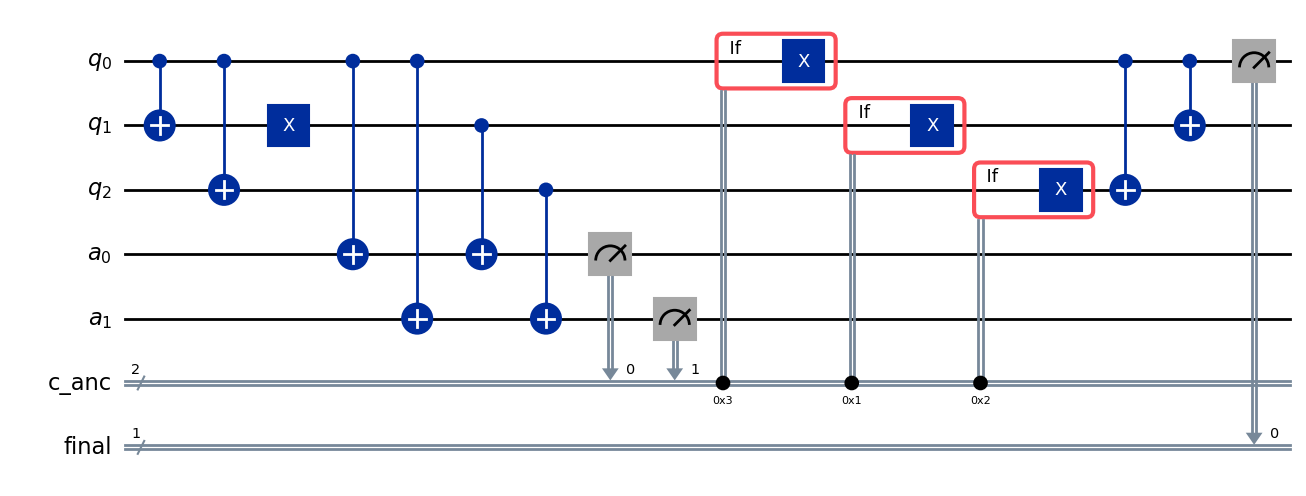

In [45]:
counts_0, fig_0 = run_and_plot(qc_0, "qc_0")
fig_0

Wyniki dla obwodu 'qc_half': {'0 10': 1000}


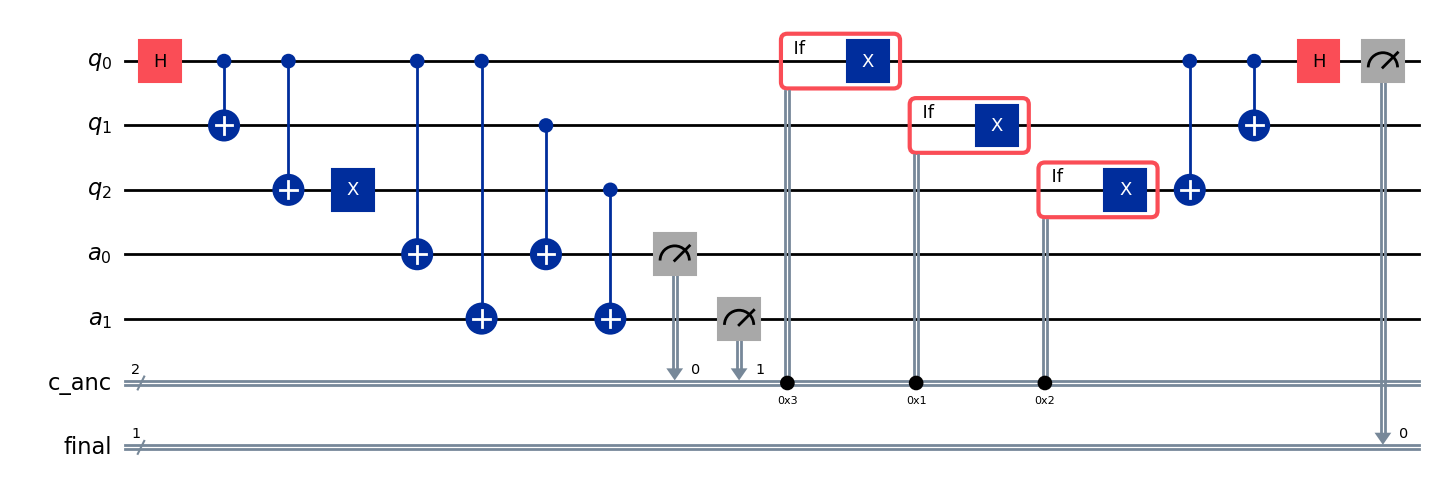

In [46]:
counts_half, fig_half = run_and_plot(qc_half, "qc_half")
fig_half

Wyniki dla obwodu 'qc_1': {'0 11': 1000}


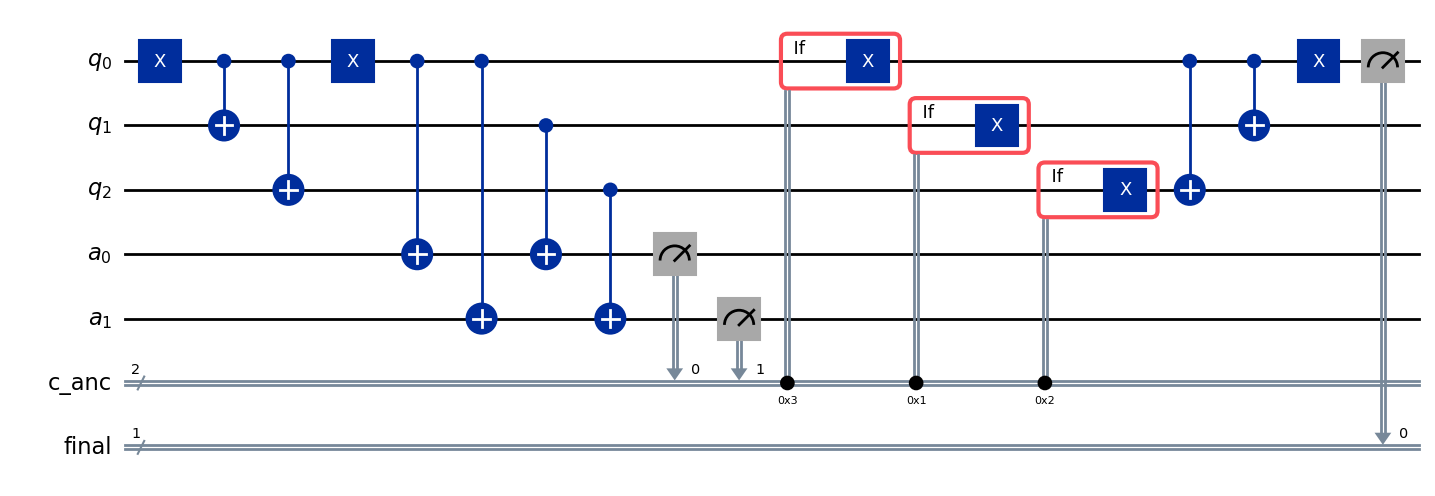

In [47]:
counts_1, fig_1 = run_and_plot(qc_1, "qc_1")
fig_1

# task 2 & 3

1000
Wyniki dla obwodu 'qc_half2': {'0 00': 1000}


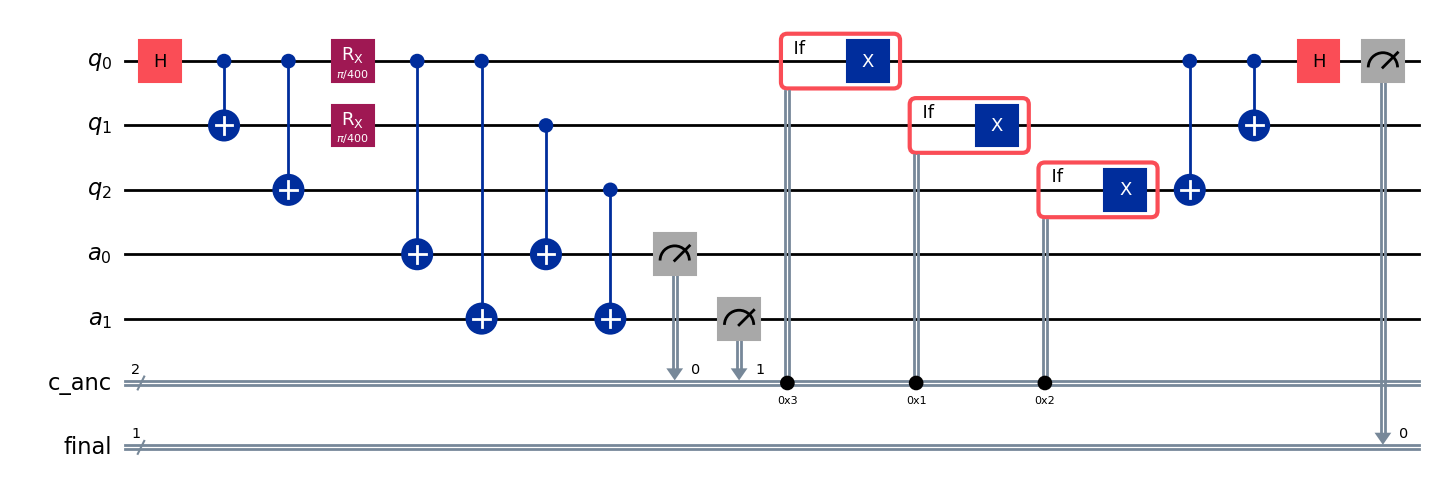

In [ ]:
# test if x -> rx works
qc_half2 = create_circuit_bitflip_error_correction2(define_q0_state = 'half', theta = np.pi/400)
prob_02, fig_02 = run_and_plot2(qc_half2, "qc_half2")
fig_02

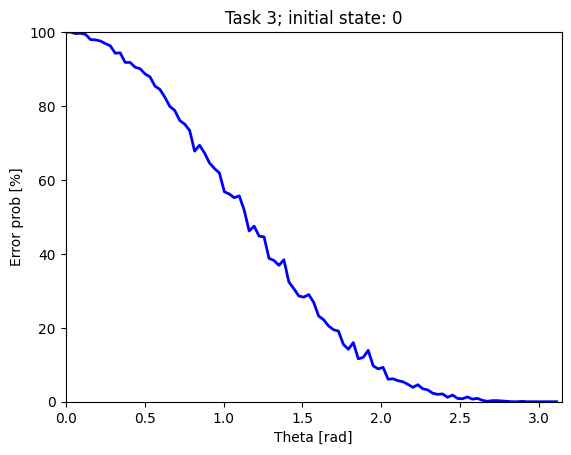

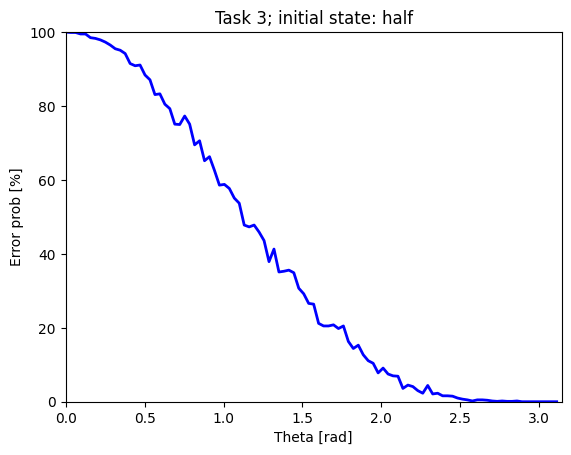

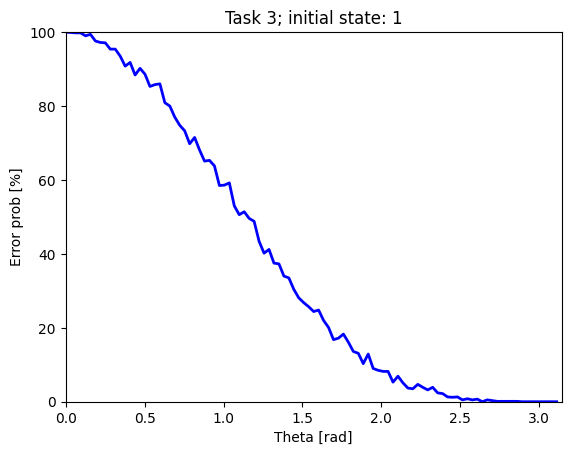

In [133]:
plot_probabilities_vs_theta(define_q0_state='0')
plot_probabilities_vs_theta(define_q0_state='half')
plot_probabilities_vs_theta(define_q0_state='1')
